In [1]:
import numpy as np

from lab.sinus_vs_square_hard.data import create_data
from quantum_learn.build_f import BuildFQuadratures, BuildFQuadraturesPolynomials, BuildFPhotonDistribution
from quantum_simulation.history import StateHistory
from quantum_simulation.jpc_chip import JpcChip
from quantum_simulation.parameters_and_constants import JPCConfig, QuantumParameters

G:\Mon Drive\PycharmProjects\Quantum-Learn\quantum_simulation\history\photon_distribution.py:222: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(self.time_interval, jnp.sqrt(self.Delta_Na), label=r"$\Delta N_a$")


In [2]:
def J(F: np.ndarray, Y: np.ndarray) -> float:
    """
    Calcule le score de séparabilité de Fisher pour des données multidimensionnelles.
    F : Matrice (n_samples, n_features)
    Y : Vecteur de labels (0 ou 1)
    """

    class1 = F[Y == 1, :]
    class2 = F[Y == 0, :]

    print(class1.shape)
    print(class2.shape)

    m1 = np.mean(class1, axis=0)
    m2 = np.mean(class2, axis=0)

    s1 = np.cov(class1, rowvar=False)
    s2 = np.cov(class2, rowvar=False)
    Sw = s1 + s2

    diff = m1 - m2

    inv_Sw_diff = np.linalg.solve(Sw, diff)
    score = diff.dot(inv_Sw_diff)

    return float(score)

In [3]:
nb_periods_train = 20

X_train_base, Y_train_base = create_data(nb_periods_train)
X_train, Y_train = X_train_base.reshape(-1), Y_train_base.reshape(-1)

X_train.shape, Y_train.shape

((160,), (160,))

In [4]:
params_G = [QuantumParameters(g_conv=700, g_sq=70, epsilon_a=130, epsilon_b=130, delta_a=0, delta_b=0)]

jpc_config = JPCConfig(
    DIM_A=10,
    DIM_B=10,
    OMEGA_A=1e4,
    OMEGA_B=9 * 1e3,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0,
    K_BB=0,
    K_AB=0,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=10
)

QP = jpc_config
chip = JpcChip(QP)
state_history: StateHistory = chip.run_simulation(X_train, params_G)[0]

|██████████| 100.0% ◆ elapsed 02m22s ◆ remaining 0.00ms  


In [5]:
build_f_quadratures = BuildFQuadratures(jpc_config)
build_f_quadratures_polynomials = BuildFQuadraturesPolynomials(jpc_config)
build_f_photon_distribution = BuildFPhotonDistribution(jpc_config)

F_quad = build_f_quadratures(state_history)
F_quad_poly = build_f_quadratures_polynomials(state_history)
F_photon = build_f_photon_distribution(state_history)

print(F_quad.shape)

(160, 40)


In [6]:
print(J(F_quad, Y_train))
print(J(F_quad_poly, Y_train))

(120, 40)
(40, 40)
nan
(120, 140)
(40, 140)
nan


C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2887: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


In [7]:
from zeroth.all import *

X_train_quad = F_quad
X_train_poly = F_quad_poly
X_train_photon = F_photon
Y_train_data = Y_train[:, None]

X_train_quad.shape, X_train_poly.shape, X_train_photon.shape, Y_train_data.shape

((160, 40), (160, 140), (160, 1000), (160, 1))

In [8]:
data_quad = Data(X_train_quad, Y_train_data, X_train_quad, Y_train_data, 2)
data_poly = Data(X_train_poly, Y_train_data, X_train_poly, Y_train_data, 2)
data_photon = Data(X_train_photon, Y_train_data, X_train_photon, Y_train_data, 2)

In [9]:
nn = NeuralNetworkConfig(name="linear", hidden_dims=[], activations=[Softmax()])
optimizer = FirstOrderAdamConfig(learning_rate=0.05,
                                 beta1=0.9,
                                 beta2=0.99,
                                 epsilon=1e-8)
model_config = FirstOrderModelConfig(name="linear",
                                     id={},
                                     loss=CrossEntropy(),
                                     metric=Accuracy(),
                                     batch_size=nb_periods_train,
                                     nb_epochs=100,
                                     neural_network_config=nn,
                                     optimizer_config=optimizer)
model_config.summary()

FirstOrderModelConfig(
    name='linear',
    id={},
    loss=CrossEntropy(),
    metric=Accuracy(),
    batch_size=20,
    nb_epochs=100,
    neural_network_config=NeuralNetworkConfig(
        name='linear',
        hidden_dims=[],
        activations=[
            Softmax()
        ]
    ),
    optimizer_config=FirstOrderAdamConfig(
        learning_rate=0.05,
        beta1=0.9,
        beta2=0.99,
        epsilon=1e-08
    )
)


In [10]:
model_quad = model_config.instantiate(data_quad)
model_quad.name = "model_quad"

model_poly = model_config.instantiate(data_poly)
model_poly.name = "model_poly"

model_photon = model_config.instantiate(data_photon)
model_photon.name = "model_photon"

models = [model_quad, model_poly, model_photon]

In [11]:
for model in models:
    model.train()

C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\zeroth\utils\activation_functions.py:40: RuntimeWarning: invalid value encountered in subtract
  shift_x = x - np.max(x, axis=-1, keepdims=True)


    Training {} Model
        epoch n°1 out of 100
    {} accuracy : 0.25, loss : nan
        epoch n°2 out of 100
    {} accuracy : 0.25, loss : nan
        epoch n°3 out of 100
    {} accuracy : 0.25, loss : nan
        epoch n°4 out of 100
    {} accuracy : 0.25, loss : nan
        epoch n°5 out of 100
    {} accuracy : 0.25, loss : nan
        epoch n°6 out of 100
    {} accuracy : 0.25, loss : nan
        epoch n°7 out of 100
    {} accuracy : 0.25, loss : nan
        epoch n°8 out of 100
    {} accuracy : 0.25, loss : nan
        epoch n°9 out of 100
    {} accuracy : 0.25, loss : nan
        epoch n°10 out of 100
    {} accuracy : 0.25, loss : nan
        epoch n°11 out of 100
    {} accuracy : 0.25, loss : nan
        epoch n°12 out of 100
    {} accuracy : 0.25, loss : nan
        epoch n°13 out of 100
    {} accuracy : 0.25, loss : nan
        epoch n°14 out of 100
    {} accuracy : 0.25, loss : nan
        epoch n°15 out of 100
    {} accuracy : 0.25, loss : nan
        epoc

C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\zeroth\first_order\layer.py:50: RuntimeWarning: invalid value encountered in matmul
  self.Z = X @ self.W + self.B


    {} accuracy : 0.25, loss : nan
        epoch n°99 out of 100
    {} accuracy : 0.25, loss : nan
        epoch n°100 out of 100
    {} accuracy : 0.25, loss : nan
    Training {} Model
        epoch n°1 out of 100
    {} accuracy : 0.75, loss : 0.5600850509437474
        epoch n°2 out of 100
    {} accuracy : 0.75, loss : 0.5606843352839626
        epoch n°3 out of 100
    {} accuracy : 0.75, loss : 0.5553328439934495
        epoch n°4 out of 100
    {} accuracy : 0.75, loss : 0.5548139286590686
        epoch n°5 out of 100
    {} accuracy : 0.75, loss : 0.552531169288587
        epoch n°6 out of 100
    {} accuracy : 0.75, loss : 0.5553130472494809
        epoch n°7 out of 100
    {} accuracy : 0.75, loss : 0.5514001630000135
        epoch n°8 out of 100
    {} accuracy : 0.74375, loss : 0.5492237967495941
        epoch n°9 out of 100
    {} accuracy : 0.75, loss : 0.5488756020173431
        epoch n°10 out of 100
    {} accuracy : 0.75, loss : 0.548334838765524
        epoch n°11 o

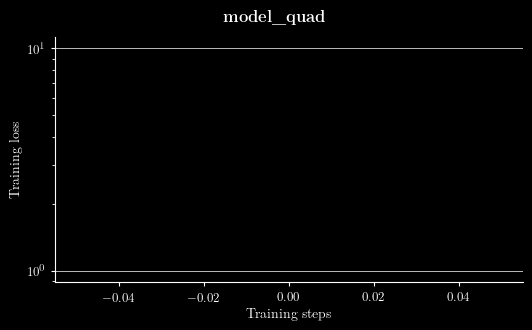

In [12]:
model_quad.plot_loss(0.05)

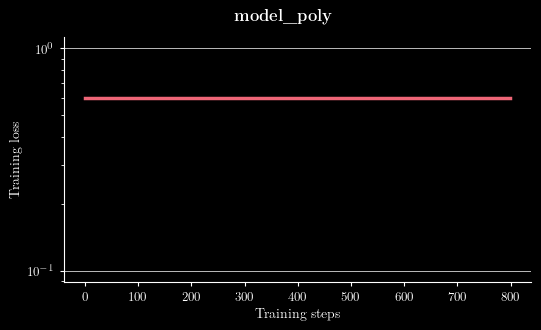

In [13]:
model_poly.plot_loss(0.05)

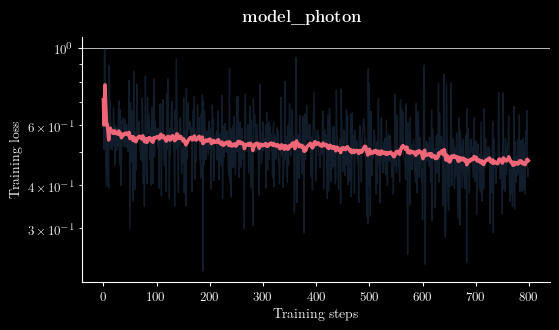

In [14]:
model_photon.plot_loss(0.05)

In [15]:
for model in models:
    model.test()

    {} accuracy : 0.25, loss : nan
    {} accuracy : 0.25, loss : nan
    {} accuracy : 0.80625, loss : 0.4764460159090601


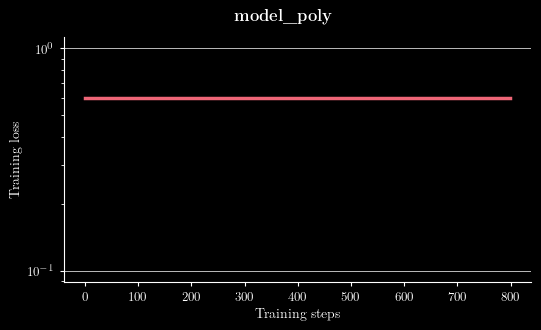

In [16]:
model_poly.plot_loss(0.05)